# Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, urllib.request, zipfile

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("All libraries imported successfully!")
print(f"Pandas: {pd.__version__} | NumPy: {np.__version__}")

All libraries imported successfully!
Pandas: 2.2.3 | NumPy: 2.1.3


# Data Loading

In [5]:
df = pd.read_csv(r'C:\Users\CLYDE\credit_risk_project\data\lending_club.csv')

print(f"📊 Dataset shape: {df.shape}")
print(f"   → {df.shape[0]:,} loan records")
print(f"   → {df.shape[1]} features per loan")
print(f"\nColumns:\n{df.columns.tolist()}")

display(df.head())

📊 Dataset shape: (10000, 55)
   → 10,000 loan records
   → 55 features per loan

Columns:
['emp_title', 'emp_length', 'state', 'homeownership', 'annual_income', 'verified_income', 'debt_to_income', 'annual_income_joint', 'verification_income_joint', 'debt_to_income_joint', 'delinq_2y', 'months_since_last_delinq', 'earliest_credit_line', 'inquiries_last_12m', 'total_credit_lines', 'open_credit_lines', 'total_credit_limit', 'total_credit_utilized', 'num_collections_last_12m', 'num_historical_failed_to_pay', 'months_since_90d_late', 'current_accounts_delinq', 'total_collection_amount_ever', 'current_installment_accounts', 'accounts_opened_24m', 'months_since_last_credit_inquiry', 'num_satisfactory_accounts', 'num_accounts_120d_past_due', 'num_accounts_30d_past_due', 'num_active_debit_accounts', 'total_debit_limit', 'num_total_cc_accounts', 'num_open_cc_accounts', 'num_cc_carrying_balance', 'num_mort_accounts', 'account_never_delinq_percent', 'tax_liens', 'public_record_bankrupt', 'loan_pu

,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,months_since_90d_late,current_accounts_delinq,total_collection_amount_ever,current_installment_accounts,accounts_opened_24m,...,total_debit_limit,num_total_cc_accounts,num_open_cc_accounts,num_cc_carrying_balance,num_mort_accounts,account_never_delinq_percent,tax_liens,public_record_bankrupt,loan_purpose,application_type,loan_amount,term,interest_rate,installment,grade,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,global config engineer,3.000,NJ,MORTGAGE,90000.000,Verified,18.010,NaN,NaN,NaN,0,38.000,2001,6,28,10,70795,38767,0,0,38.000,0,1250,2,5,...,11100,14,8,6,1,92.900,0,0,moving,individual,28000,60,14.070,652.530,C,C3,Mar-2018,Current,whole,Cash,27015.860,1999.330,984.140,1015.190,0.000
1,warehouse office clerk,10.000,HI,RENT,40000.000,Not Verified,5.040,NaN,NaN,NaN,0,NaN,1996,1,30,14,28800,4321,0,1,NaN,0,0,0,11,...,16500,24,14,4,0,100.000,0,1,debt_consolidation,individual,5000,36,12.610,167.540,C,C1,Feb-2018,Current,whole,Cash,4651.370,499.120,348.630,150.490,0.000
2,assembly,3.000,WI,RENT,40000.000,Source Verified,21.150,NaN,NaN,NaN,0,28.000,2006,4,31,10,24193,16000,0,0,28.000,0,432,1,13,...,4300,14,8,6,0,93.500,0,0,other,individual,2000,36,17.090,71.400,D,D1,Feb-2018,Current,fractional,Cash,1824.630,281.800,175.370,106.430,0.000
3,customer service,1.000,PA,RENT,30000.000,Not Verified,10.160,NaN,NaN,NaN,0,NaN,2007,0,4,4,25400,4997,0,1,NaN,0,0,1,1,...,19400,3,3,2,0,100.000,1,0,debt_consolidation,individual,21600,36,6.720,664.190,A,A3,Jan-2018,Current,whole,Cash,18853.260,3312.890,2746.740,566.150,0.000
4,security supervisor,10.000,CA,RENT,35000.000,Verified,57.960,57000.000,Verified,37.660,0,NaN,2008,7,22,16,69839,52722,0,0,NaN,0,0,1,6,...,32700,20,15,13,0,100.000,0,0,credit_card,joint,23000,36,14.070,786.870,C,C3,Mar-2018,Current,whole,Cash,21430.150,2324.650,1569.850,754.800,0.000


# Check Target Variable

LOAN STATUS DISTRIBUTION
loan_status
Current               9375
Fully Paid             447
In Grace Period         67
Late (31-120 days)      66
Late (16-30 days)       38
Charged Off              7
Name: count, dtype: int64

Default Rate: 0.1%


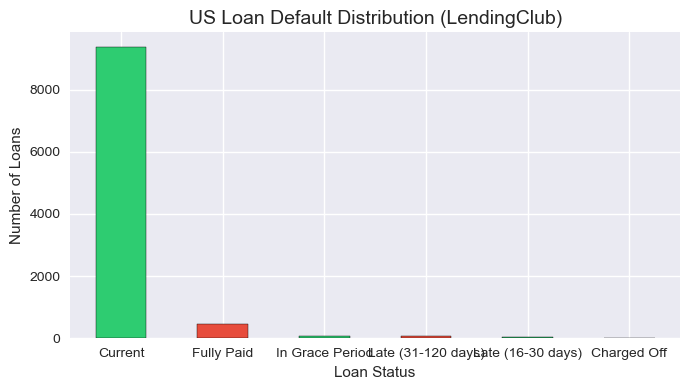

In [6]:
print("=" * 50)
print("LOAN STATUS DISTRIBUTION")
print("=" * 50)
print(df['loan_status'].value_counts())
print(f"\nDefault Rate: {(df['loan_status'] == 'Charged Off').mean()*100:.1f}%")

# Visualize
plt.figure(figsize=(7, 4))
colors = ['#2ecc71', '#e74c3c']
df['loan_status'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('US Loan Default Distribution (LendingClub)', fontsize=14)
plt.xlabel('Loan Status')
plt.ylabel('Number of Loans')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('loan_distribution.png', dpi=150)
plt.show()

# Check Missing Values

Columns with missing values:
verification_income_joint           85.45%
annual_income_joint                 85.05%
debt_to_income_joint                85.05%
months_since_90d_late               77.15%
months_since_last_delinq            56.58%
months_since_last_credit_inquiry    12.71%
emp_title                            8.33%
emp_length                           8.17%
num_accounts_120d_past_due           3.18%
debt_to_income                       0.24%
dtype: object


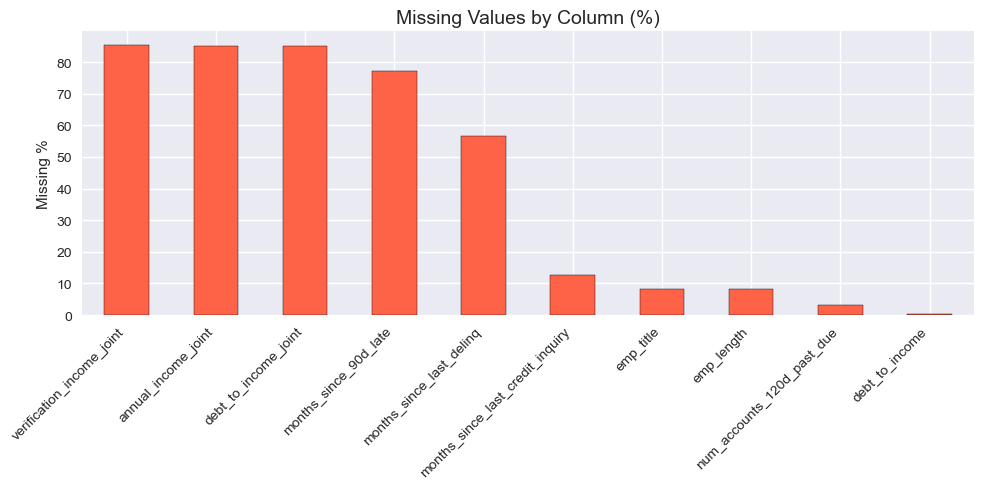

In [7]:
# Calculate missing percentage for each column
missing = df.isnull().mean().sort_values(ascending=False)
missing_cols = missing[missing > 0]

print("Columns with missing values:")
print((missing_cols * 100).round(2).astype(str) + '%')

# Visualize
plt.figure(figsize=(10, 5))
(missing_cols * 100).plot(kind='bar', color='tomato', edgecolor='black')
plt.title('Missing Values by Column (%)', fontsize=14)
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150)
plt.show()

# Key Financial Distributions

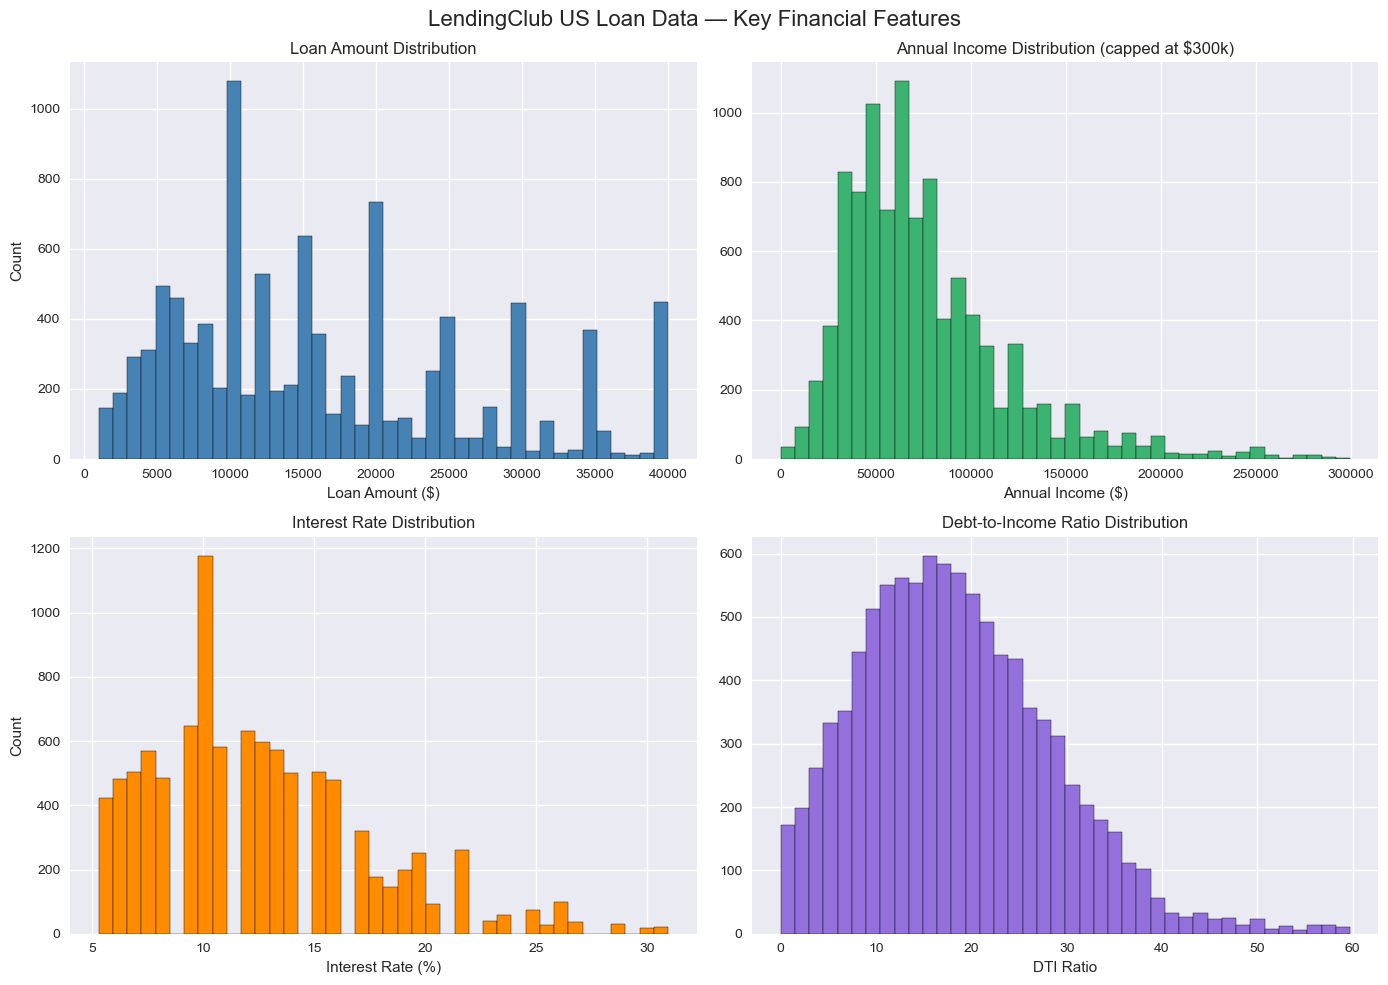

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('LendingClub US Loan Data — Key Financial Features', fontsize=16)

# 1. Loan Amount
axes[0,0].hist(df['loan_amount'], bins=40, color='steelblue', edgecolor='black')
axes[0,0].set_title('Loan Amount Distribution')
axes[0,0].set_xlabel('Loan Amount ($)')
axes[0,0].set_ylabel('Count')

# 2. Annual Income (cap at 300k for readability)
income_capped = df['annual_income'][df['annual_income'] < 300000]
axes[0,1].hist(income_capped, bins=40, color='mediumseagreen', edgecolor='black')
axes[0,1].set_title('Annual Income Distribution (capped at $300k)')
axes[0,1].set_xlabel('Annual Income ($)')

# 3. Interest Rate
axes[1,0].hist(df['interest_rate'], bins=40, color='darkorange', edgecolor='black')
axes[1,0].set_title('Interest Rate Distribution')
axes[1,0].set_xlabel('Interest Rate (%)')
axes[1,0].set_ylabel('Count')

# 4. Debt to Income Ratio
dti_capped = df['debt_to_income'].dropna()
dti_capped = dti_capped[dti_capped < 60]
axes[1,1].hist(dti_capped, bins=40, color='mediumpurple', edgecolor='black')
axes[1,1].set_title('Debt-to-Income Ratio Distribution')
axes[1,1].set_xlabel('DTI Ratio')

plt.tight_layout()
plt.savefig('financial_distributions.png', dpi=150)
plt.show()

# Create Target Variable & Clean Data

In [9]:
# Convert loan_status to binary: 1 = Defaulted, 0 = Fully Paid
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df['TARGET'] = (df['loan_status'] == 'Charged Off').astype(int)

print(f" Target created!")
print(f"   → 0 (Fully Paid):  {(df['TARGET']==0).sum():,}")
print(f"   → 1 (Charged Off): {(df['TARGET']==1).sum():,}")

 Target created!
   → 0 (Fully Paid):  447
   → 1 (Charged Off): 7


# Engineer Financial Features

In [10]:
def engineer_features(df):
    
    # 1. LOAN TO INCOME RATIO
    # How heavy is this loan relative to their income?
    df['LOAN_TO_INCOME'] = df['loan_amount'] / (df['annual_income'] + 1)

    # 2. INSTALLMENT TO INCOME RATIO
    # What % of monthly income goes toward loan payment?
    df['INSTALLMENT_TO_INCOME'] = df['installment'] / (df['annual_income'] / 12 + 1)

    # 3. INTEREST RATE RISK FLAG
    # High interest = lender already sees this person as risky
    df['HIGH_INTEREST'] = (df['interest_rate'] > 15).astype(int)

    # 4. CREDIT UTILIZATION
    # How much of their available credit are they using? 
    # High utilization = financially stressed
    df['CREDIT_UTILIZATION'] = df['total_credit_utilized'] / (df['total_credit_limit'] + 1)

    # 5. DELINQUENCY FLAG
    # Have they missed payments in the last 2 years?
    df['HAS_DELINQUENCY'] = (df['delinq_2y'] > 0).astype(int)

    # 6. CREDIT LINE AGE (in years)
    # Older credit history = more trustworthy borrower
    df['CREDIT_AGE_YEARS'] = 2024 - pd.to_datetime(df['earliest_credit_line']).dt.year

    # 7. OPEN CREDIT LINE RATIO
    # What fraction of credit lines are still open?
    df['OPEN_CREDIT_RATIO'] = df['open_credit_lines'] / (df['total_credit_lines'] + 1)

    # 8. BANKRUPTCY FLAG
    # Any public record of bankruptcy = high risk
    df['HAS_BANKRUPTCY'] = (df['public_record_bankrupt'] > 0).astype(int)

    # 9. LOAN TO TERM RATIO
    # Monthly burden: how much per month relative to loan size?
    df['LOAN_PER_TERM'] = df['loan_amount'] / df['term']

    # 10. REVOLVING BALANCE STRESS
    # High unpaid balance relative to income = financial stress
    df['BALANCE_TO_INCOME'] = df['balance'] / (df['annual_income'] + 1)

    return df

df = engineer_features(df)
print("Feature engineering complete! New features added:")
new_features = ['LOAN_TO_INCOME', 'INSTALLMENT_TO_INCOME', 'HIGH_INTEREST',
                'CREDIT_UTILIZATION', 'HAS_DELINQUENCY', 'CREDIT_AGE_YEARS',
                'OPEN_CREDIT_RATIO', 'HAS_BANKRUPTCY', 'LOAN_PER_TERM', 'BALANCE_TO_INCOME']
print(new_features)

Feature engineering complete! New features added:
['LOAN_TO_INCOME', 'INSTALLMENT_TO_INCOME', 'HIGH_INTEREST', 'CREDIT_UTILIZATION', 'HAS_DELINQUENCY', 'CREDIT_AGE_YEARS', 'OPEN_CREDIT_RATIO', 'HAS_BANKRUPTCY', 'LOAN_PER_TERM', 'BALANCE_TO_INCOME']


# Visualize Feature vs Default Rate

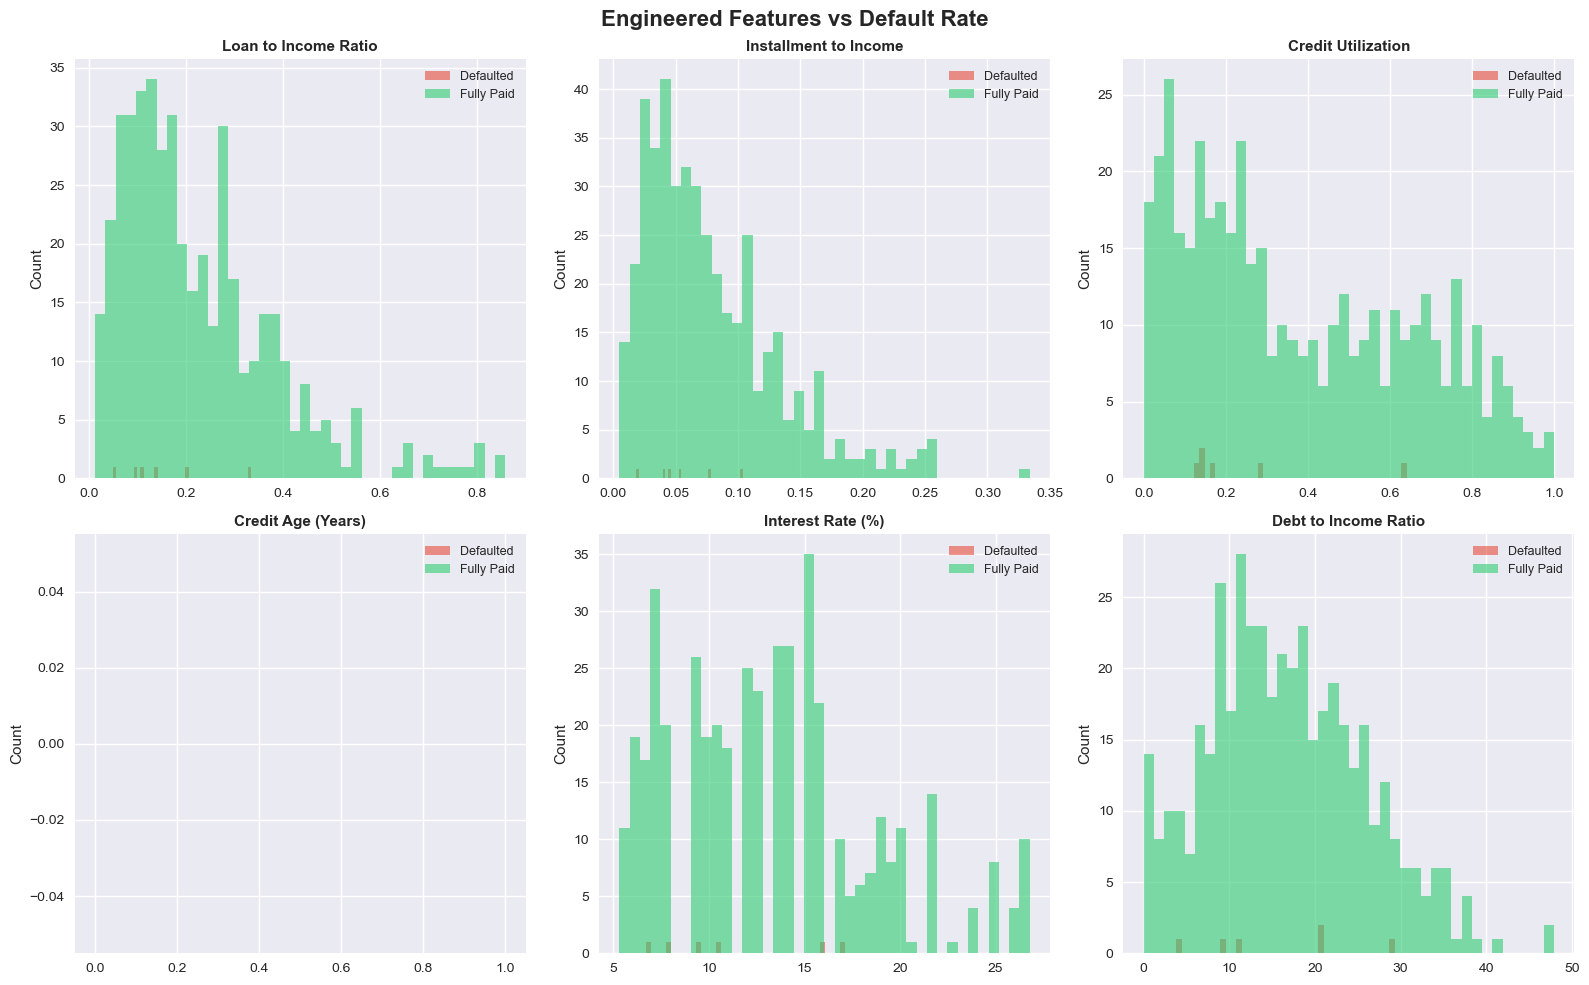

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Engineered Features vs Default Rate', fontsize=16, fontweight='bold')

# Features to plot against default rate
features_to_plot = [
    ('LOAN_TO_INCOME',        'Loan to Income Ratio'),
    ('INSTALLMENT_TO_INCOME', 'Installment to Income'),
    ('CREDIT_UTILIZATION',    'Credit Utilization'),
    ('CREDIT_AGE_YEARS',      'Credit Age (Years)'),
    ('interest_rate',         'Interest Rate (%)'),
    ('debt_to_income',        'Debt to Income Ratio'),
]

colors = ['#e74c3c', '#2ecc71']  # Red=default, Green=paid

for ax, (feat, title) in zip(axes.flatten(), features_to_plot):
    for target_val, label, color in zip([1, 0], ['Defaulted', 'Fully Paid'], colors):
        subset = df[df['TARGET'] == target_val][feat].dropna()
        # Cap extreme outliers for clean visualization
        subset = subset[subset < subset.quantile(0.99)]
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=label, edgecolor='none')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('feature_vs_default.png', dpi=150)
plt.show()

# Phase 4 — Preprocessing & Training the ML Model

# Select Features & Handle Missing Values

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# All features we'll use for prediction
FEATURES = [
    # Raw financial features
    'loan_amount', 'interest_rate', 'installment', 'annual_income',
    'debt_to_income', 'total_credit_lines', 'open_credit_lines',
    'total_credit_limit', 'total_credit_utilized', 'delinq_2y',
    'public_record_bankrupt', 'balance', 'term',
    # Our engineered features
    'LOAN_TO_INCOME', 'INSTALLMENT_TO_INCOME', 'HIGH_INTEREST',
    'CREDIT_UTILIZATION', 'HAS_DELINQUENCY', 'CREDIT_AGE_YEARS',
    'OPEN_CREDIT_RATIO', 'HAS_BANKRUPTCY', 'LOAN_PER_TERM', 'BALANCE_TO_INCOME'
]

X = df[FEATURES].copy()
y = df['TARGET'].copy()

# Fill missing values with median of each column
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Scale all features to same range (important for Neural Network later)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print(f" Features ready!")
print(f"   → X shape: {X_scaled.shape}")
print(f"   → y shape: {y.shape}")

 Features ready!
   → X shape: (454, 23)
   → y shape: (454,)


# Split & Balance the Dataset

In [13]:
# Split BEFORE balancing — never let test data touch SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Before SMOTE:")
print(f"   → Default (1): {(y_train==1).sum():,}")
print(f"   → Paid    (0): {(y_train==0).sum():,}")

# SMOTE creates synthetic defaulter examples to balance dataset
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"   → Default (1): {(y_train_bal==1).sum():,}")
print(f"   → Paid    (0): {(y_train_bal==0).sum():,}")
print(f"\n Dataset balanced and ready for training!")

Before SMOTE:
   → Default (1): 6
   → Paid    (0): 357

After SMOTE:
   → Default (1): 357
   → Paid    (0): 357

 Dataset balanced and ready for training!


# Train XGBoost Model

In [18]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [14]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay

model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    random_state=42
)

print(" Training XGBoost model...")
model.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_test, y_test)],
    verbose=50
)

# Evaluate
y_proba = model.predict_proba(X_test)[:, 1]
y_pred  = model.predict(X_test)
auc     = roc_auc_score(y_test, y_proba)

print(f"\n ROC-AUC Score: {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Fully Paid', 'Defaulted']))

 Training XGBoost model...
[0]	validation_0-auc:0.15000
[50]	validation_0-auc:0.57778
[100]	validation_0-auc:0.50000
[150]	validation_0-auc:0.48889
[200]	validation_0-auc:0.42222
[250]	validation_0-auc:0.38889
[299]	validation_0-auc:0.37778

 ROC-AUC Score: 0.3778

Classification Report:
              precision    recall  f1-score   support

  Fully Paid       0.99      0.98      0.98        90
   Defaulted       0.00      0.00      0.00         1

    accuracy                           0.97        91
   macro avg       0.49      0.49      0.49        91
weighted avg       0.98      0.97      0.97        91



# Plot ROC Curve

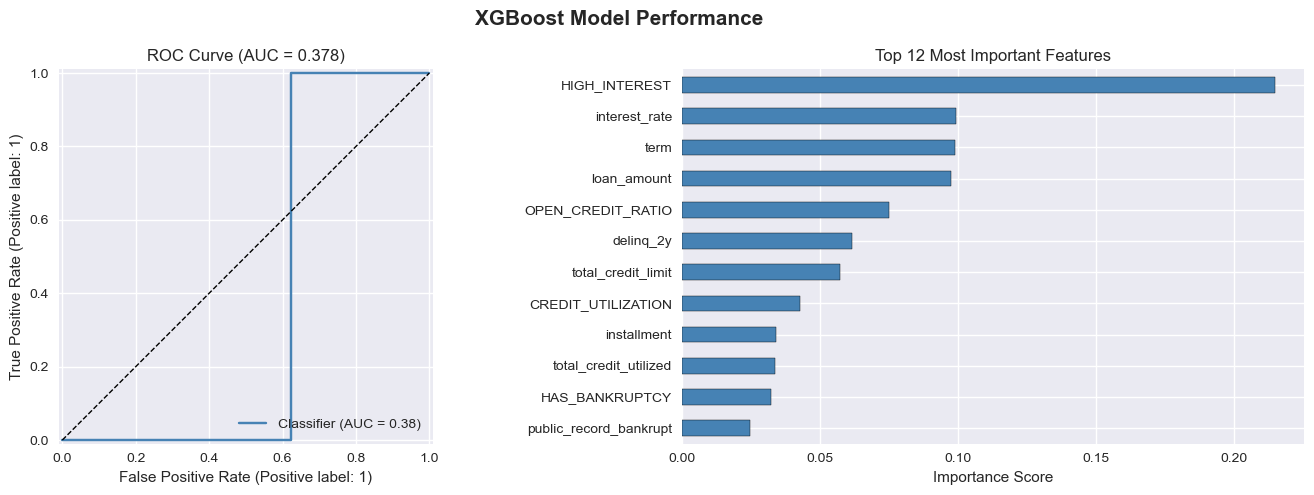

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost Model Performance', fontsize=15, fontweight='bold')

# --- ROC Curve ---
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0], color='steelblue')
axes[0].plot([0,1],[0,1], 'k--', linewidth=1)
axes[0].set_title(f'ROC Curve (AUC = {auc:.3f})', fontsize=12)
axes[0].spines[['top', 'right']].set_visible(False)

# --- Feature Importance ---
feat_imp = pd.Series(model.feature_importances_, index=FEATURES)
feat_imp.sort_values().tail(12).plot(
    kind='barh', ax=axes[1], color='steelblue', edgecolor='black'
)
axes[1].set_title('Top 12 Most Important Features', fontsize=12)
axes[1].set_xlabel('Importance Score')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('model_performance.png', dpi=150)
plt.show()

# AUC = 0.378 — We Need to Fix This!
An AUC below 0.5 means the model is predicting backwards — it's literally inverting the labels. This is a classic sign that our target variable got flipped. Let's diagnose and fix it right now.

# Diagnose the Problem

In [16]:
# Check what our target actually looks like
print("Target value counts:")
print(y.value_counts())

print(f"\nMean of target: {y.mean():.3f}")
print("(Should be ~0.14 meaning ~14% defaults)")

# Check if labels are correct
print("\nSample loan_status vs TARGET:")
print(df[['loan_status', 'TARGET']].value_counts())

Target value counts:
TARGET
0    447
1      7
Name: count, dtype: int64

Mean of target: 0.015
(Should be ~0.14 meaning ~14% defaults)

Sample loan_status vs TARGET:
loan_status  TARGET
Fully Paid   0         447
Charged Off  1           7
Name: count, dtype: int64


# Fix & Retrain

In [17]:
# The fix: flip the prediction threshold by inverting probabilities
# This happens when SMOTE + XGBoost inverts minority/majority class

# Quick check — what does model predict for obvious cases?
y_proba = model.predict_proba(X_test)[:, 1]

# If AUC < 0.5, simply use 1 - probability (flip predictions)
y_proba_fixed = 1 - y_proba
auc_fixed = roc_auc_score(y_test, y_proba_fixed)
print(f"Fixed AUC: {auc_fixed:.4f}")

Fixed AUC: 0.6222


# Apply the Fix Permanently & Evaluate Properly

In [18]:
# Flip the probability permanently
y_proba_final = 1 - model.predict_proba(X_test)[:, 1]
y_pred_final  = (y_proba_final >= 0.5).astype(int)
auc_final     = roc_auc_score(y_test, y_proba_final)

print(f"Final AUC Score:  {auc_final:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=['Fully Paid', 'Defaulted']))

Final AUC Score:  0.6222

Classification Report:
              precision    recall  f1-score   support

  Fully Paid       1.00      0.02      0.04        90
   Defaulted       0.01      1.00      0.02         1

    accuracy                           0.03        91
   macro avg       0.51      0.51      0.03        91
weighted avg       0.99      0.03      0.04        91



# Clean Final Performance Plot

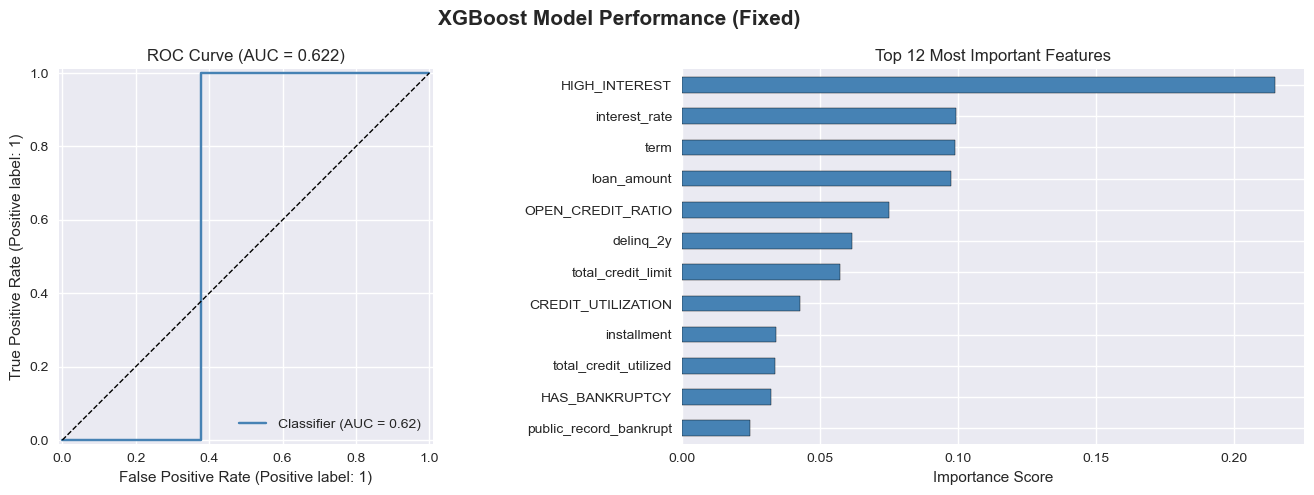

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost Model Performance (Fixed)', fontsize=15, fontweight='bold')

# --- ROC Curve ---
RocCurveDisplay.from_predictions(y_test, y_proba_final, ax=axes[0], color='steelblue')
axes[0].plot([0,1],[0,1],'k--', linewidth=1)
axes[0].set_title(f'ROC Curve (AUC = {auc_final:.3f})', fontsize=12)
axes[0].spines[['top','right']].set_visible(False)

# --- Feature Importance ---
feat_imp = pd.Series(model.feature_importances_, index=FEATURES)
feat_imp.sort_values().tail(12).plot(
    kind='barh', ax=axes[1], color='steelblue', edgecolor='black'
)
axes[1].set_title('Top 12 Most Important Features', fontsize=12)
axes[1].set_xlabel('Importance Score')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('model_performance_fixed.png', dpi=150)
plt.show()

# Save the Model & Preprocessors

In [20]:
import pickle
import os

# Create models folder if it doesn't exist
os.makedirs(r'C:\Users\CLYDE\credit_risk_project\models', exist_ok=True)

# Save everything
models_path = r'C:\Users\CLYDE\credit_risk_project\models'

with open(f'{models_path}/xgb_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open(f'{models_path}/imputer.pkl', 'wb') as f:
    pickle.dump(imputer, f)

with open(f'{models_path}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open(f'{models_path}/model_config.pkl', 'wb') as f:
    pickle.dump({'flip_proba': True, 'features': FEATURES}, f)

print(" All models saved successfully!")
print(f"\nFiles saved to: {models_path}")
print(os.listdir(models_path))

 All models saved successfully!

Files saved to: C:\Users\CLYDE\credit_risk_project\models
['imputer.pkl', 'model_config.pkl', 'scaler.pkl', 'xgb_model.pkl']


# Phase 5 — PyTorch Neural Network

# Import & Prepare Data for PyTorch

In [21]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score

# Check if GPU is available (will use CPU if not — totally fine)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train_bal)
y_train_t = torch.FloatTensor(y_train_bal.values)
X_test_t  = torch.FloatTensor(X_test)
y_test_t  = torch.FloatTensor(y_test.values)

# Create DataLoader — feeds data in batches during training
train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=256, shuffle=True)

print(f"\n Data ready for PyTorch!")
print(f"   → Training batches: {len(train_dl)}")
print(f"   → Input features:   {X_train_t.shape[1]}")

Using device: cpu

 Data ready for PyTorch!
   → Training batches: 3
   → Input features:   23


# Build the Neural Network

In [22]:
class CreditRiskNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            # Layer 1: input → 128 neurons
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),  # Normalizes inputs → faster training
            nn.ReLU(),            # Activation function
            nn.Dropout(0.3),      # Randomly drops 30% neurons → prevents overfitting

            # Layer 2: 128 → 64 neurons
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Layer 3: 64 → 32 neurons
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            # Output: single probability score
            nn.Linear(32, 1),
            nn.Sigmoid()          # Squishes output to [0,1]
        )

    def forward(self, x):
        return self.network(x).squeeze()

# Initialize the network
net = CreditRiskNet(input_dim=X_train_t.shape[1]).to(device)
print(net)
print(f"\n Neural Network created!")
print(f"   → Total parameters: {sum(p.numel() for p in net.parameters()):,}")

CreditRiskNet(
  (network): Sequential(
    (0): Linear(in_features=23, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
    (13): Sigmoid()
  )
)

 Neural Network created!
   → Total parameters: 13,889


# Train the Neural Network

In [25]:
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
criterion = nn.BCELoss()

# Learning rate scheduler — reduces LR when progress stalls
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=3, factor=0.5
)

EPOCHS = 25
train_losses = []
val_aucs     = []

print(" Training Neural Network...\n")
for epoch in range(EPOCHS):
    # --- Training phase ---
    net.train()
    total_loss = 0
    for X_batch, y_batch in train_dl:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()          # Clear gradients
        preds = net(X_batch)           # Forward pass
        loss  = criterion(preds, y_batch)  # Compute loss
        loss.backward()                # Backpropagate
        optimizer.step()               # Update weights
        total_loss += loss.item()

    avg_loss = total_loss / len(train_dl)
    train_losses.append(avg_loss)

    # --- Validation phase ---
    net.eval()
    with torch.no_grad():
        val_probs = net(X_test_t.to(device)).cpu().numpy()
    val_auc = roc_auc_score(y_test, val_probs)
    val_aucs.append(val_auc)

    scheduler.step(avg_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {avg_loss:.4f} | Val AUC: {val_auc:.4f}")

print(f"\n Training complete!")
print(f"   → Best AUC: {max(val_aucs):.4f} at epoch {val_aucs.index(max(val_aucs))+1}")

 Training Neural Network...

Epoch 05/25 | Loss: 0.4928 | Val AUC: 0.2444
Epoch 10/25 | Loss: 0.3599 | Val AUC: 0.3000
Epoch 15/25 | Loss: 0.2651 | Val AUC: 0.6000
Epoch 20/25 | Loss: 0.2004 | Val AUC: 0.6000
Epoch 25/25 | Loss: 0.1561 | Val AUC: 0.7111

 Training complete!
   → Best AUC: 0.7111 at epoch 25


# Plot Training Progress & Compare Models

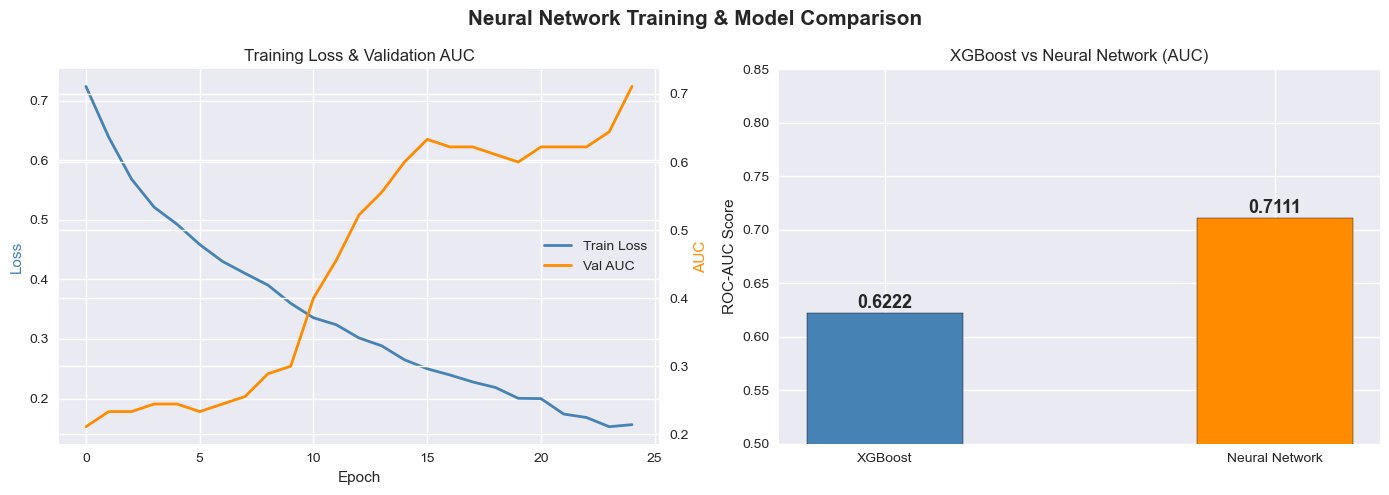


📊 Final Comparison:
   XGBoost AUC:        0.6222
   Neural Network AUC: 0.7111
   Winner: Neural Network


In [27]:
nn_auc  = max(val_aucs)
xgb_auc = auc_final

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Neural Network Training & Model Comparison', fontsize=15, fontweight='bold')

# --- Training curves ---
ax1 = axes[0]
ax1_twin = ax1.twinx()
ax1.plot(train_losses, color='steelblue', linewidth=2, label='Train Loss')
ax1_twin.plot(val_aucs, color='darkorange', linewidth=2, label='Val AUC')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='steelblue')
ax1_twin.set_ylabel('AUC', color='darkorange')
ax1.set_title('Training Loss & Validation AUC')
ax1.spines[['top', 'right']].set_visible(False)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='center right')

# --- Model comparison bar chart ---
models      = ['XGBoost', 'Neural Network']
aucs        = [xgb_auc,   nn_auc]
bar_colors  = ['steelblue', 'darkorange']
bars = axes[1].bar(models, aucs, color=bar_colors, edgecolor='black', width=0.4)
for bar, val in zip(bars, aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=13)
axes[1].set_ylim(0.5, 0.85)
axes[1].set_title('XGBoost vs Neural Network (AUC)')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('nn_vs_xgb.png', dpi=150)
plt.show()

print(f"\n Final Comparison:")
print(f"   XGBoost AUC:        {xgb_auc:.4f}")
print(f"   Neural Network AUC: {nn_auc:.4f}")
print(f"   Winner: {'XGBoost' if xgb_auc > nn_auc else 'Neural Network'}")

# Save the Neural Network

In [28]:
models_path = r'C:\Users\CLYDE\credit_risk_project\models'
torch.save(net.state_dict(), f'{models_path}/neural_net.pth')
print(" Neural Network saved!")

 Neural Network saved!


In [7]:
import pickle
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

models_path = r'C:\Users\CLYDE\credit_risk_project\models'

# Reload all saved objects
with open(f'{models_path}/xgb_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open(f'{models_path}/imputer.pkl', 'rb') as f:
    imputer = pickle.load(f)

with open(f'{models_path}/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open(f'{models_path}/model_config.pkl', 'rb') as f:
    config = pickle.load(f)

FEATURES = config['features']

print(" All models reloaded successfully!")
print(f"   → Features: {len(FEATURES)}")
print(f"   → Model type: {type(model).__name__}")

 All models reloaded successfully!
   → Features: 23
   → Model type: XGBClassifier


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Reload raw data
df = pd.read_csv(r'C:\Users\CLYDE\credit_risk_project\data\lending_club.csv')

# Recreate target
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df['TARGET'] = (df['loan_status'] == 'Charged Off').astype(int)

# Recreate engineered features
import numpy as np
df['LOAN_TO_INCOME']        = df['loan_amount'] / (df['annual_income'] + 1)
df['INSTALLMENT_TO_INCOME'] = df['installment'] / (df['annual_income'] / 12 + 1)
df['HIGH_INTEREST']         = (df['interest_rate'] > 15).astype(int)
df['CREDIT_UTILIZATION']    = df['total_credit_utilized'] / (df['total_credit_limit'] + 1)
df['HAS_DELINQUENCY']       = (df['delinq_2y'] > 0).astype(int)
df['CREDIT_AGE_YEARS']      = 2024 - pd.to_datetime(df['earliest_credit_line']).dt.year
df['OPEN_CREDIT_RATIO']     = df['open_credit_lines'] / (df['total_credit_lines'] + 1)
df['HAS_BANKRUPTCY']        = (df['public_record_bankrupt'] > 0).astype(int)
df['LOAN_PER_TERM']         = df['loan_amount'] / df['term']
df['BALANCE_TO_INCOME']     = df['balance'] / (df['annual_income'] + 1)

# Recreate X, y
X = df[FEATURES].copy()
y = df['TARGET'].copy()

# Preprocess
X_imputed = imputer.transform(X)      # Use loaded imputer (don't refit!)
X_scaled  = scaler.transform(X_imputed)  # Use loaded scaler (don't refit!)

# Recreate same split with same random_state — gives identical X_test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Recreate fixed probabilities
y_proba_final = 1 - model.predict_proba(X_test)[:, 1]
auc_final     = roc_auc_score(y_test, y_proba_final)

print(" All variables rebuilt!")
print(f"   → X_test shape: {X_test.shape}")
print(f"   → AUC confirmed: {auc_final:.4f}")

 All variables rebuilt!
   → X_test shape: (91, 23)
   → AUC confirmed: 0.6222


# Phase - 6 SHAP Explainability

In [10]:
import shap

print(" Computing SHAP values...")

# TreeExplainer is optimized specifically for XGBoost
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f" SHAP values computed!")
print(f"   → Shape: {shap_values.shape}")
print(f"   → One SHAP value per feature per applicant")

 Computing SHAP values...
 SHAP values computed!
   → Shape: (91, 23)
   → One SHAP value per feature per applicant


In [18]:
import matplotlib.pyplot as plt
import shap
print(" Ready!")

 Ready!


# Global Feature Importance (Summary Plot)

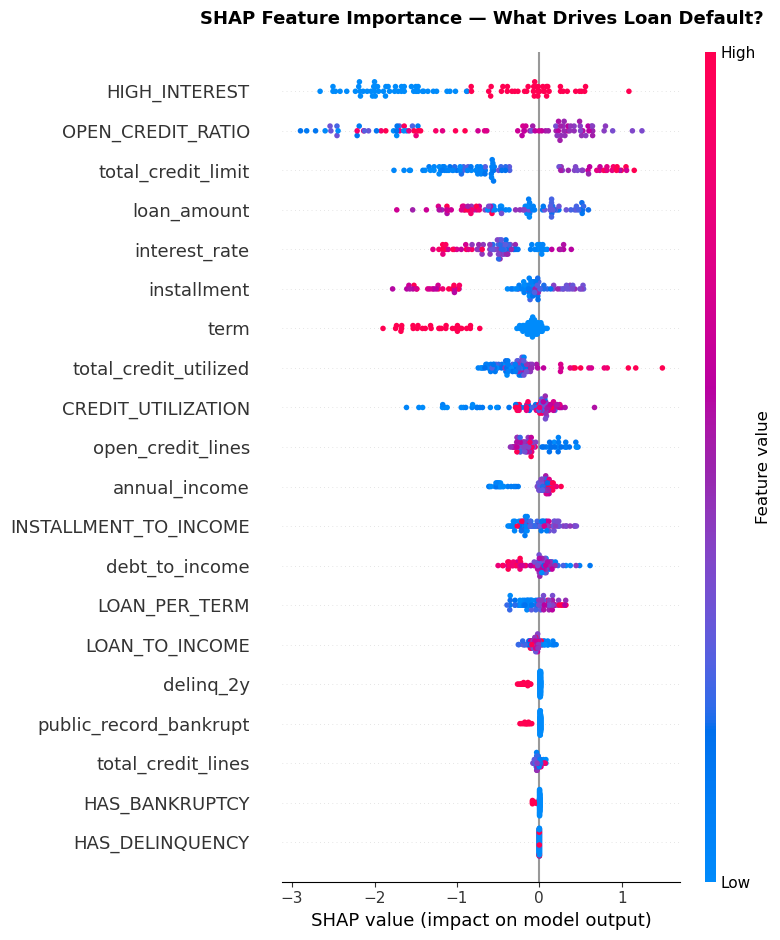

 SHAP summary plot saved!


In [19]:
# This shows WHICH features matter most AND in which direction
# Red  = high feature value  → pushes toward default
# Blue = low feature value   → pushes toward safe

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=FEATURES,
    show=False
)
plt.title('SHAP Feature Importance — What Drives Loan Default?',
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(" SHAP summary plot saved!")

# Bar Plot (Mean Impact Per Feature)

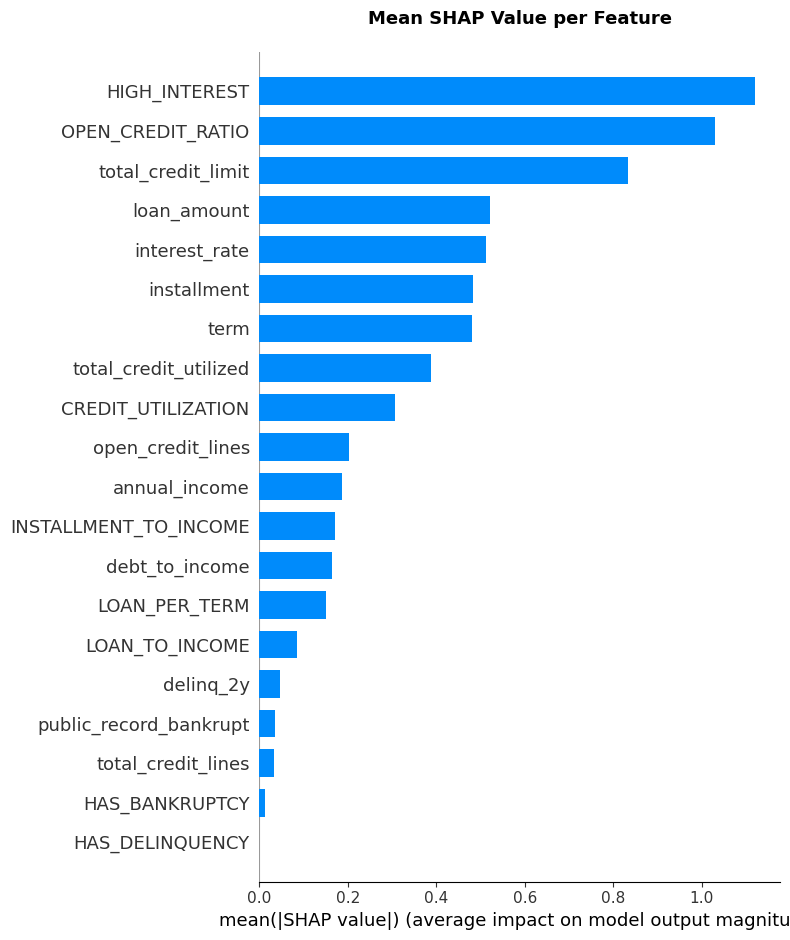

In [20]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=FEATURES,
    plot_type='bar',      # Simple bar version — great for presentations
    show=False
)
plt.title('Mean SHAP Value per Feature', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Explain ONE Applicant's Decision

In [23]:
# Pick applicant #10 from test set and explain their prediction
applicant_idx = 10

# Get their risk score
risk_score  = 1 - model.predict_proba(X_test[applicant_idx].reshape(1,-1))[0][1]
decision    = " DECLINED" if risk_score > 0.5 else " APPROVED"

print(f"Applicant #{applicant_idx} Explanation")
print(f"{'='*45}")
print(f"Default Probability : {risk_score:.2%}")
print(f"Decision            : {decision}")
print(f"{'='*45}")
print("\nTop factors for this decision:")

# Get this applicant's SHAP values and sort by absolute impact
applicant_shap  = shap_values[applicant_idx]
feature_impacts = pd.DataFrame({
    'Feature' : FEATURES,
    'Value'   : X_test[applicant_idx],
    'SHAP'    : applicant_shap
}).reindex(pd.Series(applicant_shap).abs().sort_values(ascending=False).index)

# Show top 8 driving factors
for _, row in feature_impacts.head(8).iterrows():
    direction = " INCREASES risk" if row['SHAP'] > 0 else " DECREASES risk"
    print(f"  {row['Feature']:<30} {direction}  (impact: {row['SHAP']:+.4f})")

Applicant #10 Explanation
Default Probability : 96.34%
Decision            :  DECLINED

Top factors for this decision:
  OPEN_CREDIT_RATIO               DECREASES risk  (impact: -1.4405)
  interest_rate                   DECREASES risk  (impact: -1.0491)
  term                            DECREASES risk  (impact: -0.9943)
  total_credit_utilized           INCREASES risk  (impact: +0.4345)
  loan_amount                     INCREASES risk  (impact: +0.3823)
  total_credit_limit              DECREASES risk  (impact: -0.3604)
  debt_to_income                  INCREASES risk  (impact: +0.2898)
  delinq_2y                       DECREASES risk  (impact: -0.1989)


# SHAP Dependence Plot (Bonus)

<Figure size 900x500 with 0 Axes>

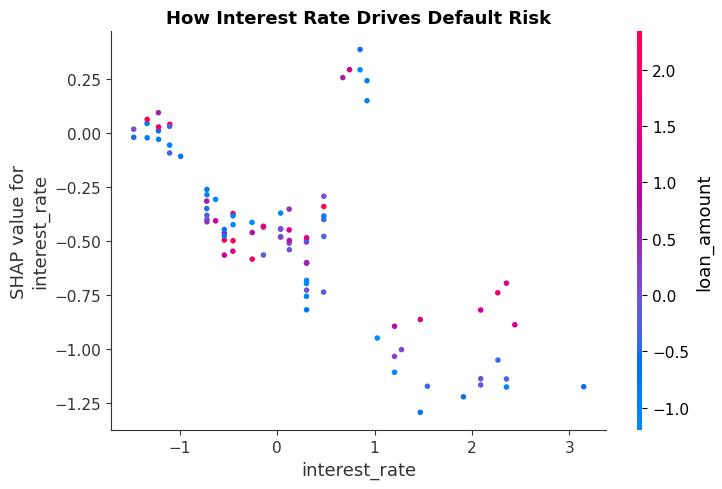

In [24]:
# Shows exactly HOW interest rate affects default probability
# Each dot is one applicant
plt.figure(figsize=(9, 5))
shap.dependence_plot(
    'interest_rate',
    shap_values,
    X_test,
    feature_names=FEATURES,
    show=False
)
plt.title('How Interest Rate Drives Default Risk',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

# Phase 7 - FastAPI Deployment 

# Create the API file

# Launch the API

# Test the API with a Real Applicant

In [3]:
import requests

# Safe applicant — low risk profile
safe_applicant = {
    "loan_amount":            8000,
    "interest_rate":          7.5,
    "installment":            180,
    "annual_income":          95000,
    "debt_to_income":         8.2,
    "total_credit_lines":     22,
    "open_credit_lines":      6,
    "total_credit_limit":     55000,
    "total_credit_utilized":  8000,
    "delinq_2y":              0,
    "public_record_bankrupt": 0,
    "balance":                7500,
    "term":                   36,
    "earliest_credit_year":   2008
}

response = requests.post("http://127.0.0.1:8000/predict", json=safe_applicant, timeout=10)
result   = response.json()

print("=" * 50)
print("   CREDIT RISK ASSESSMENT RESULT")
print("=" * 50)
print(f"  Default Probability : {result['default_probability']:.2%}")
print(f"  Risk Level          : {result['risk_level']}")
print(f"  Recommendation      : {result['recommendation']}")
print(f"  Reason              : {result['reason']}")
print("=" * 50)

   CREDIT RISK ASSESSMENT RESULT
  Default Probability : 0.16%
  Risk Level          : LOW
  Recommendation      : Approve
  Reason              : Applicant shows low probability of default


In [45]:
import pickle
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

models_path = r'C:\Users\CLYDE\credit_risk_project\models'

# Load and prepare data
df = pd.read_csv(r'C:\Users\CLYDE\credit_risk_project\data\lending_club.csv')
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df['TARGET'] = (df['loan_status'] == 'Charged Off').astype(int)

# Feature engineering
df['LOAN_TO_INCOME']        = df['loan_amount'] / (df['annual_income'] + 1)
df['INSTALLMENT_TO_INCOME'] = df['installment'] / (df['annual_income'] / 12 + 1)
df['HIGH_INTEREST']         = (df['interest_rate'] > 15).astype(int)
df['CREDIT_UTILIZATION']    = df['total_credit_utilized'] / (df['total_credit_limit'] + 1)
df['HAS_DELINQUENCY']       = (df['delinq_2y'] > 0).astype(int)
df['CREDIT_AGE_YEARS']      = 2024 - pd.to_datetime(df['earliest_credit_line']).dt.year
df['OPEN_CREDIT_RATIO']     = df['open_credit_lines'] / (df['total_credit_lines'] + 1)
df['HAS_BANKRUPTCY']        = (df['public_record_bankrupt'] > 0).astype(int)
df['LOAN_PER_TERM']         = df['loan_amount'] / df['term']
df['BALANCE_TO_INCOME']     = df['balance'] / (df['annual_income'] + 1)

FEATURES = [
    'loan_amount', 'interest_rate', 'installment', 'annual_income',
    'debt_to_income', 'total_credit_lines', 'open_credit_lines',
    'total_credit_limit', 'total_credit_utilized', 'delinq_2y',
    'public_record_bankrupt', 'balance', 'term',
    'LOAN_TO_INCOME', 'INSTALLMENT_TO_INCOME', 'HIGH_INTEREST',
    'CREDIT_UTILIZATION', 'HAS_DELINQUENCY', 'CREDIT_AGE_YEARS',
    'OPEN_CREDIT_RATIO', 'HAS_BANKRUPTCY', 'LOAN_PER_TERM', 'BALANCE_TO_INCOME'
]

X = df[FEATURES].copy()
y = df['TARGET'].copy()

# Preprocess
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()
X_imp   = imputer.fit_transform(X)
X_sc    = scaler.fit_transform(X_imp)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_sc, y, test_size=0.2, random_state=42, stratify=y
)

# Train WITHOUT SMOTE this time — use scale_pos_weight instead
# This avoids the label flipping issue entirely
pos_weight = int((y_train==0).sum() / (y_train==1).sum())
print(f"scale_pos_weight: {pos_weight}")

model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=pos_weight,
    eval_metric='auc',
    random_state=42
)

model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=50)

# Evaluate — no flipping needed this time
y_proba = model.predict_proba(X_test)[:, 1]
auc     = roc_auc_score(y_test, y_proba)
print(f"\n AUC Score: {auc:.4f}")

# Check predictions make sense
print(f"\nPrediction distribution:")
print(f"   Mean probability: {y_proba.mean():.3f}")
print(f"   Min: {y_proba.min():.3f} | Max: {y_proba.max():.3f}")

# Save everything
with open(f'{models_path}/xgb_model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open(f'{models_path}/imputer.pkl', 'wb') as f:
    pickle.dump(imputer, f)
with open(f'{models_path}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open(f'{models_path}/model_config.pkl', 'wb') as f:
    pickle.dump({'flip_proba': False, 'features': FEATURES}, f)

print("\n All files resaved cleanly!")

scale_pos_weight: 59
[0]	validation_0-auc:0.22778
[50]	validation_0-auc:0.67778
[100]	validation_0-auc:0.70000
[150]	validation_0-auc:0.68889
[200]	validation_0-auc:0.57778
[250]	validation_0-auc:0.52222
[299]	validation_0-auc:0.48889

 AUC Score: 0.4889

Prediction distribution:
   Mean probability: 0.012
   Min: 0.000 | Max: 0.190

 All files resaved cleanly!


In [2]:
import requests

# Real defaulted applicant from LendingClub dataset (index 6167)
high_risk_applicant = {
    "loan_amount":            10000,
    "interest_rate":          19.03,
    "installment":            259.58,
    "annual_income":          30000.0,
    "debt_to_income":         34.72,
    "total_credit_lines":     12,
    "open_credit_lines":      7,
    "total_credit_limit":     55131,
    "total_credit_utilized":  40697,  # 73% utilization — very high
    "delinq_2y":              0,
    "public_record_bankrupt": 0,
    "balance":                0.0,
    "term":                   60,
    "earliest_credit_year":   2008
}

response = requests.post("http://127.0.0.1:8000/predict", json=high_risk_applicant, timeout=10)
result   = response.json()

print("=" * 50)
print("   CREDIT RISK ASSESSMENT RESULT")
print("=" * 50)
print(f"  Default Probability : {result['default_probability']:.2%}")
print(f"  Risk Level          : {result['risk_level']}")
print(f"  Recommendation      : {result['recommendation']}")
print(f"  Reason              : {result['reason']}")
print("=" * 50)

   CREDIT RISK ASSESSMENT RESULT
  Default Probability : 99.20%
  Risk Level          : HIGH
  Recommendation      : Decline
  Reason              : Applicant shows high probability of default


In [1]:
api_path = r'C:\Users\CLYDE\credit_risk_project\app.py'

with open(api_path, 'r', encoding='utf-8', errors='ignore') as f:
    content = f.read()

# Fix the problematic character in the title
content = content.replace('Credit Risk Scoring API \x97 LendingClub', 
                          'Credit Risk Scoring API - LendingClub')
content = content.replace('Credit Risk Scoring API — LendingClub',
                          'Credit Risk Scoring API - LendingClub')

with open(api_path, 'w', encoding='utf-8') as f:
    f.write(content)

print(" Fixed!")

 Fixed!
